In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print("CSV files in current directory:", csv_files)

CSV files in current directory: ['Dataset - Updated.csv']


In [3]:
import pandas as pd
import numpy as np

# Load your actual dataset
df = pd.read_csv('Dataset - Updated.csv')

print("=== 1. DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== 2. COLUMN DATA TYPES & INFO ===")
df.info()

print("\n=== 3. MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n=== 4. FIRST 5 ROWS ===")
display(df.head())

=== 1. DATASET SHAPE ===
Rows: 1205, Columns: 12

=== 2. COLUMN DATA TYPES & INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB



,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Dataset - Updated.csv')

print("=" * 30 + " 1. DATASET DIMENSIONS & INFO " + "=" * 30)
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")
df.info()

print("\n" + "=" * 30 + " 2. MISSING VALUES PER COLUMN " + "=" * 30)
missing = df.isnull().sum()
print(missing)

print("\n" + "=" * 30 + " 3. NUMERICAL DESCRIPTIVE STATISTICS " + "=" * 30)
display(df.describe().T.round(2))

print("\n" + "=" * 30 + " 4. TARGET DISTRIBUTION ('Risk Level') " + "=" * 30)
print("Counts:")
print(df['Risk Level'].value_counts(dropna=False))
print("\nPercentage (%):")
print((df['Risk Level'].value_counts(dropna=False, normalize=True) * 100).round(2))

============================== 1. DATASET DIMENSIONS & INFO ==============================
Total Rows: 1205, Total Columns: 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int

,count,mean,std,min,25%,50%,75%,max
Age,1205.0,27.48,9.20,10.0,21.00,25.0,31.0,65.0
Systolic BP,1200.0,116.82,18.72,70.0,100.00,120.0,130.0,200.0
Diastolic,1201.0,77.17,14.31,40.0,65.00,80.0,90.0,140.0
BS,1203.0,7.50,3.05,3.0,6.00,6.9,7.9,19.0
Body Temp,1205.0,98.40,1.09,97.0,98.00,98.0,98.0,103.0
BMI,1187.0,23.32,3.88,0.0,20.45,23.0,25.0,37.0
Previous Complications,1203.0,0.18,0.38,0.0,0.00,0.0,0.0,1.0
Preexisting Diabetes,1203.0,0.29,0.45,0.0,0.00,0.0,1.0,1.0
Gestational Diabetes,1205.0,0.12,0.32,0.0,0.00,0.0,0.0,1.0
Mental Health,1205.0,0.33,0.47,0.0,0.00,0.0,1.0,1.0



============================== 4. TARGET DISTRIBUTION ('Risk Level') ==============================
Counts:
Risk Level
Low     713
High    474
NaN      18
Name: count, dtype: int64

Percentage (%):
Risk Level
Low     59.17
High    39.34
NaN      1.49
Name: proportion, dtype: float64


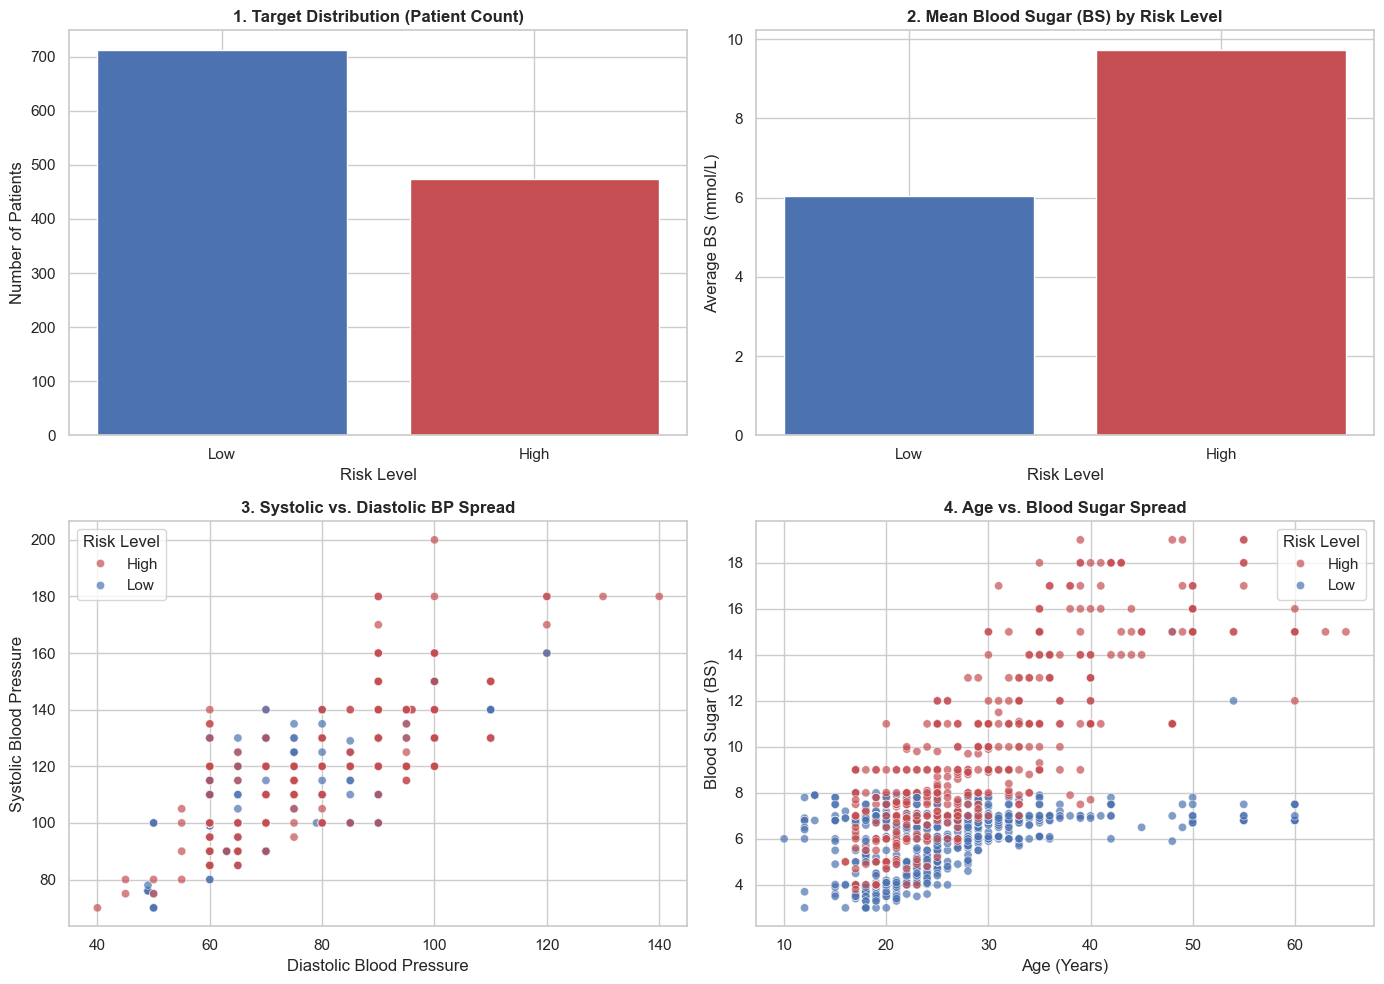

Step 2 completed: 4 visual charts generated.


In [10]:
# ==============================================================================
# STEP 2: SIMPLE VISUALIZATIONS TO SPOT PATTERNS
# ==============================================================================
# What we are doing here:
# 1. Temporarily drop the 18 missing target rows so plots reflect clean labels.
# 2. Plot 1 (Bar Chart): Inspect class balance between Low and High risk.
# 3. Plot 2 (Bar Chart): Compare average Blood Sugar (BS) across risk levels.
# 4. Plot 3 (Scatter Plot): Check how Systolic vs. Diastolic BP separates risk groups.
# 5. Plot 4 (Scatter Plot): Check how Age vs. Blood Sugar (BS) relates to risk.
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Clean rows missing the target variable for accurate plotting
df_plot = df.dropna(subset=['Risk Level']).copy()

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------------------------------------------------------------------------
# GRAPH 1: Target Class Count (Bar Chart)
# Goal: Verify if our dataset is heavily imbalanced.
# ------------------------------------------------------------------------------
counts = df_plot['Risk Level'].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=['#4C72B0', '#C44E52'])
axes[0, 0].set_title('1. Target Distribution (Patient Count)', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Risk Level')
axes[0, 0].set_ylabel('Number of Patients')

# ------------------------------------------------------------------------------
# GRAPH 2: Average Blood Sugar by Risk Level (Bar Chart)
# Goal: Test whether higher blood sugar correlates with High Risk.
# ------------------------------------------------------------------------------
avg_bs = df_plot.groupby('Risk Level')['BS'].mean().loc[counts.index]
axes[0, 1].bar(avg_bs.index, avg_bs.values, color=['#4C72B0', '#C44E52'])
axes[0, 1].set_title('2. Mean Blood Sugar (BS) by Risk Level', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Risk Level')
axes[0, 1].set_ylabel('Average BS (mmol/L)')

# ------------------------------------------------------------------------------
# GRAPH 3: Systolic BP vs. Diastolic BP (Scatter Plot)
# Goal: See if blood pressure clusters differentiate Low vs. High risk.
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=df_plot,
    x='Diastolic',
    y='Systolic BP',
    hue='Risk Level',
    palette={'Low': '#4C72B0', 'High': '#C44E52'},
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Systolic vs. Diastolic BP Spread', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Diastolic Blood Pressure')
axes[1, 0].set_ylabel('Systolic Blood Pressure')

# ------------------------------------------------------------------------------
# GRAPH 4: Age vs. Blood Sugar (Scatter Plot)
# Goal: See if older age combined with elevated blood sugar pushes patients to High Risk.
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=df_plot,
    x='Age',
    y='BS',
    hue='Risk Level',
    palette={'Low': '#4C72B0', 'High': '#C44E52'},
    alpha=0.7,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Age vs. Blood Sugar Spread', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Age (Years)')
axes[1, 1].set_ylabel('Blood Sugar (BS)')

plt.tight_layout()
plt.show()

print("Step 2 completed: 4 visual charts generated.")

========================= CORRELATION WITH HIGH RISK (1 = High, 0 = Low) =========================
Preexisting Diabetes      0.686
Mental Health             0.638
BS                        0.592
Previous Complications    0.542
BMI                       0.521
Heart Rate                0.485
Gestational Diabetes      0.448
Diastolic                 0.333
Systolic BP               0.291
Body Temp                 0.213
Age                       0.196
Name: Risk_Target_Numeric, dtype: float64


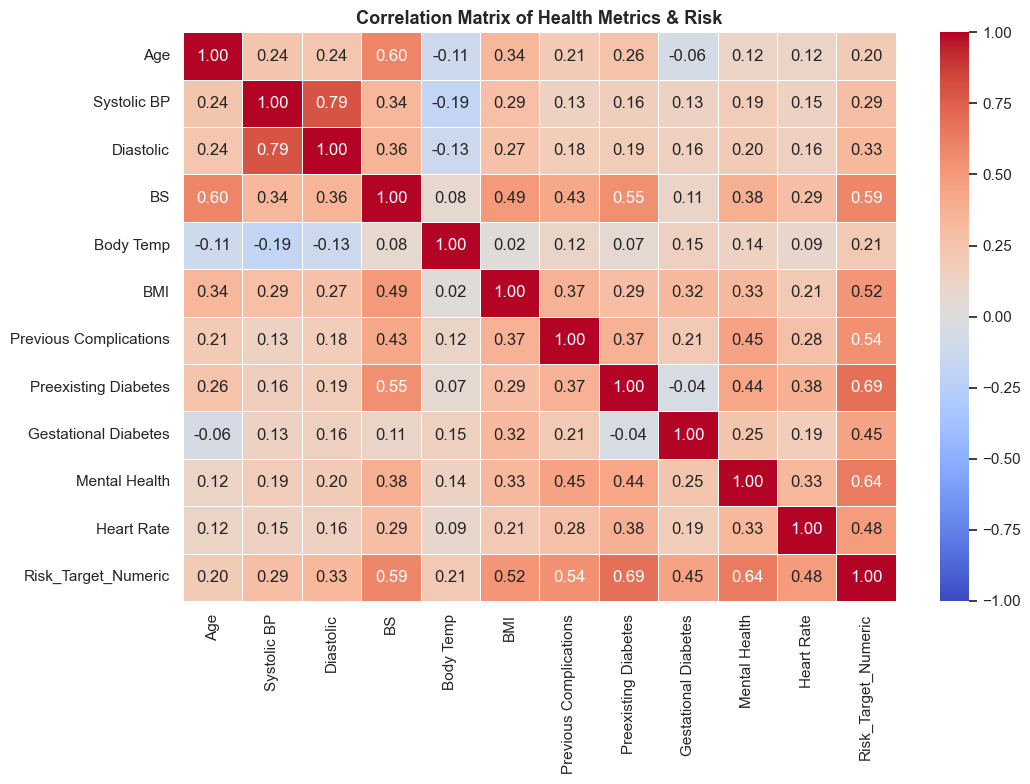


Step 3 completed: Correlation values and heatmap generated.


In [11]:
# ==============================================================================
# STEP 3: FINDING PATTERNS & CORRELATIONS BETWEEN FEATURES
# ==============================================================================
# What we are doing here:
# 1. Clean the target rows so calculations are mathematically valid.
# 2. Convert 'Risk Level' into a temporary numeric column (High = 1, Low = 0).
# 3. Rank each feature by its correlation with Risk Level (identifies key predictors).
# 4. Generate a clean correlation heatmap across all clinical features.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare clean subset for correlation analysis
df_pattern = df.dropna(subset=['Risk Level']).copy()

# 2. Map risk to numbers for correlation computation
# High Risk = 1, Low Risk = 0
df_pattern['Risk_Target_Numeric'] = df_pattern['Risk Level'].map({'Low': 0, 'High': 1})

# 3. Calculate correlation matrix across all numeric features
corr_matrix = df_pattern.select_dtypes(include=[np.number]).corr()

# 4. Extract and rank correlations directly with the Target
target_corr = corr_matrix['Risk_Target_Numeric'].drop('Risk_Target_Numeric').sort_values(ascending=False)

print("=" * 25 + " CORRELATION WITH HIGH RISK (1 = High, 0 = Low) " + "=" * 25)
print(target_corr.round(3))

# ------------------------------------------------------------------------------
# HEATMAP VISUALIZATION
# Goal: Identify strong relationships and feature redundancies at a glance
# ------------------------------------------------------------------------------
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix of Health Metrics & Risk", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

print("\nStep 3 completed: Correlation values and heatmap generated.")

In [12]:
# ==============================================================================
# STEP 4: DATA PREPARATION (PIPELINE)
# ==============================================================================
# What we are doing here:
# 1. Clean missing labels from the target column.
# 2. Separate features (X) from the prediction target (y).
# 3. Encode the target (Low -> 0, High -> 1).
# 4. Split data: 80% to train the models, 20% reserved for testing.
# 5. Impute any missing clinical features with the median.
# 6. Scale numerical features so all measurements are on an equal playing field.
# ==============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Load data and drop rows with empty target values
df_prep = pd.read_csv('Dataset - Updated.csv')
df_prep = df_prep.dropna(subset=['Risk Level']).copy()

# 2. Separate features (X) and target (y)
X = df_prep.drop(columns=['Risk Level'])
# Encode target: High Risk = 1, Low Risk = 0
y = df_prep['Risk Level'].map({'Low': 0, 'High': 1})

# 3. Train-Test Split (stratify preserves the 60/40 class proportion in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Impute missing feature values (fit ONLY on train to avoid data leakage)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 5. Standardize features (scale to mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Verification & Inspection
print("=" * 25 + " STEP 4 VERIFICATION " + "=" * 25)
print(f"Total Clean Records: {len(df_prep)}")
print(f"Training Features Shape (X_train): {X_train_scaled.shape}")
print(f"Testing Features Shape (X_test):   {X_test_scaled.shape}")
print(f"\nTraining Target Distribution:\n{y_train.value_counts().rename({0: 'Low (0)', 1: 'High (1)'})}")
print(f"\nTesting Target Distribution:\n{y_test.value_counts().rename({0: 'Low (0)', 1: 'High (1)'})}")
print("\nStep 4 completed: Data is fully split, imputed, and scaled.")

========================= STEP 4 VERIFICATION =========================
Total Clean Records: 1187
Training Features Shape (X_train): (949, 11)
Testing Features Shape (X_test):   (238, 11)

Training Target Distribution:
Risk Level
Low (0)     570
High (1)    379
Name: count, dtype: int64

Testing Target Distribution:
Risk Level
Low (0)     143
High (1)     95
Name: count, dtype: int64

Step 4 completed: Data is fully split, imputed, and scaled.


In [13]:
# ==============================================================================
# STEPS 6 & 7: TRAIN ALL THREE MODELS & EVALUATE ON TEST DATA
# ==============================================================================
# What we are doing here:
# 1. Initialize SVM, Decision Tree, and Random Forest.
# 2. Fit (train) each model using the scaled training data (X_train_scaled, y_train).
# 3. Predict classifications on the unseen test set (X_test_scaled).
# 4. Generate the full classification report and confusion matrix for each.
# ==============================================================================

import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# 1. Initialize the 3 models
models = {
    "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Train and evaluate loop
predictions = {}
metrics_list = []

for name, model in models.items():
    # Step 6: Train the model
    model.fit(X_train_scaled, y_train)
    
    # Step 7: Predict on the unseen 20% test data
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Calculate metrics for High Risk (Class 1)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics_list.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (High Risk)": round(prec, 3),
        "Recall (High Risk)": round(rec, 3),
        "F1-Score": round(f1, 3)
    })
    
    print(f"\n{'='*25} {name} {'='*25}")
    print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

print("\nModels trained and evaluated successfully.")


========================= Support Vector Machine (SVM) =========================
               precision    recall  f1-score   support

 Low Risk (0)       0.99      0.98      0.99       143
High Risk (1)       0.97      0.99      0.98        95

     accuracy                           0.98       238
    macro avg       0.98      0.98      0.98       238
 weighted avg       0.98      0.98      0.98       238


========================= Decision Tree =========================
               precision    recall  f1-score   support

 Low Risk (0)       0.98      0.98      0.98       143
High Risk (1)       0.97      0.97      0.97        95

     accuracy                           0.97       238
    macro avg       0.97      0.97      0.97       238
 weighted avg       0.97      0.97      0.97       238


========================= Random Forest =========================
               precision    recall  f1-score   support

 Low Risk (0)       0.99      0.99      0.99       143
High Ri

============================== FINAL MODEL COMPARISON ==============================


,Model,Accuracy (%),Precision (High Risk),Recall (High Risk),F1-Score
2,Random Forest,99.16,0.989,0.989,0.989
0,Support Vector Machine (SVM),98.32,0.969,0.989,0.979
1,Decision Tree,97.48,0.968,0.968,0.968


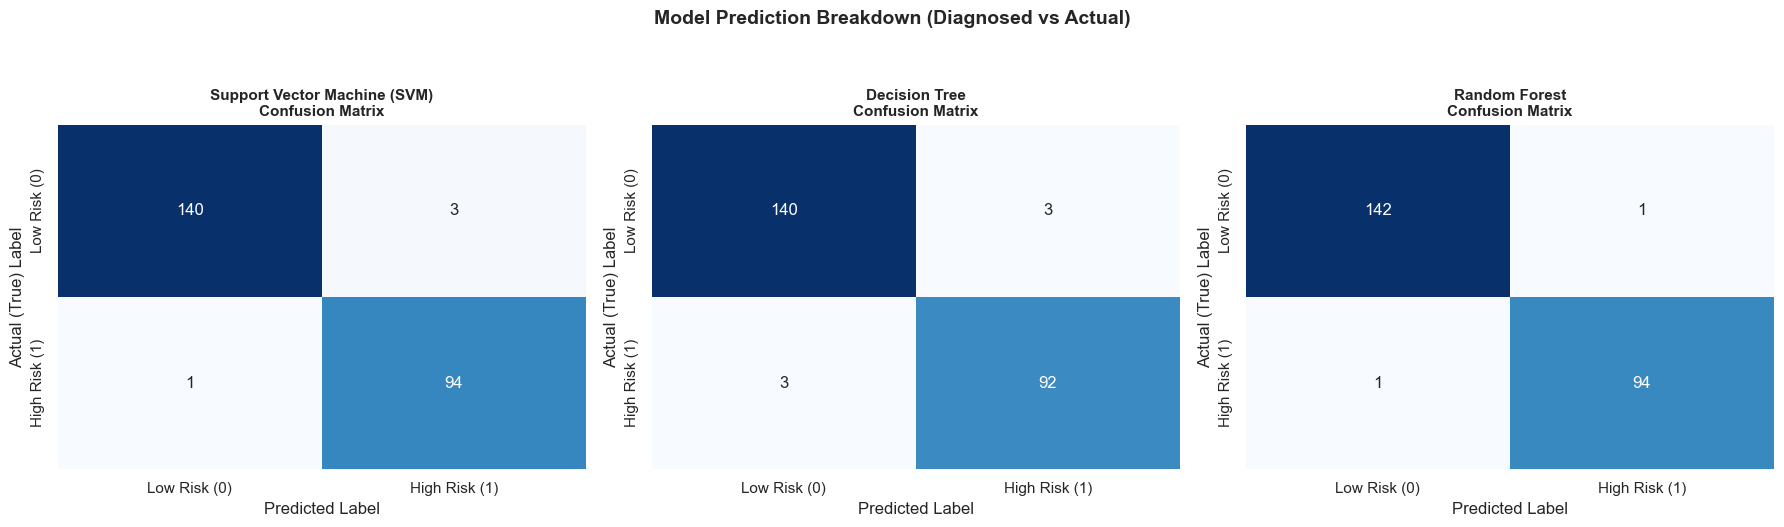

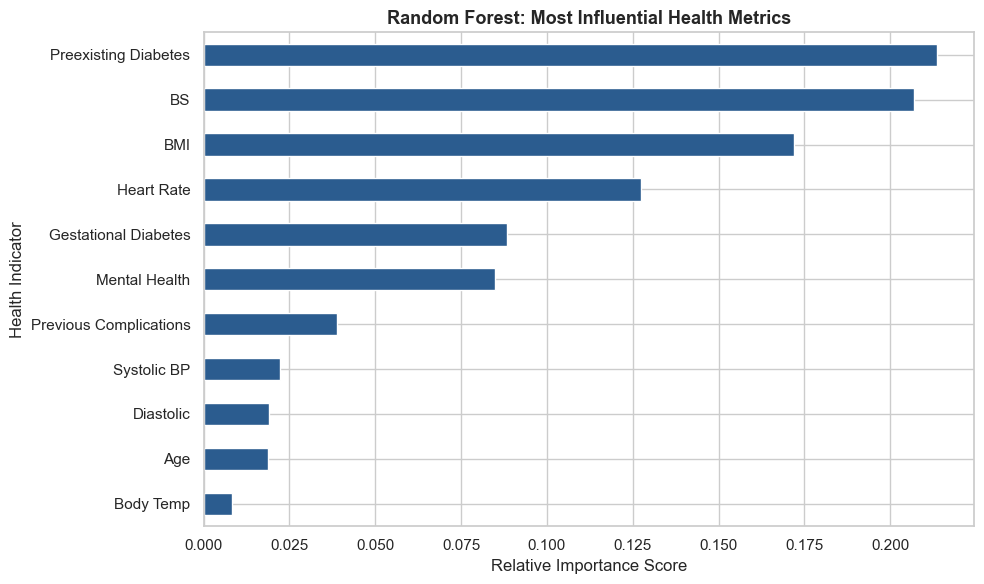


Step 8 complete: Comparison table, confusion matrices, and feature importance generated.


In [14]:
# ==============================================================================
# STEP 8: COMPARATIVE LEADERBOARD, CONFUSION MATRICES & FEATURE IMPORTANCE
# ==============================================================================
# What we are doing here:
# 1. Create a clean comparison leaderboard comparing Accuracy, Precision, Recall, F1.
# 2. Plot side-by-side Confusion Matrices to visualize exact patient errors.
# 3. Extract and plot Random Forest feature importances to see clinical drivers.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------------------------
# 1. Comparison Table
# ------------------------------------------------------------------------------
leaderboard = pd.DataFrame(metrics_list).sort_values(by="F1-Score", ascending=False)
print("=" * 30 + " FINAL MODEL COMPARISON " + "=" * 30)
display(leaderboard)

# ------------------------------------------------------------------------------
# 2. Side-by-Side Confusion Matrices
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        xticklabels=['Low Risk (0)', 'High Risk (1)'],
        yticklabels=['Low Risk (0)', 'High Risk (1)'],
        ax=ax
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=11, weight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual (True) Label")

plt.suptitle("Model Prediction Breakdown (Diagnosed vs Actual)", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. Clinical Feature Importance (From Random Forest)
# ------------------------------------------------------------------------------
rf_model = models["Random Forest"]
feature_importance = pd.Series(
    rf_model.feature_importances_, 
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='#2b5c8f')
plt.title("Random Forest: Most Influential Health Metrics", fontsize=13, weight='bold')
plt.xlabel("Relative Importance Score")
plt.ylabel("Health Indicator")
plt.tight_layout()
plt.show()

print("\nStep 8 complete: Comparison table, confusion matrices, and feature importance generated.")

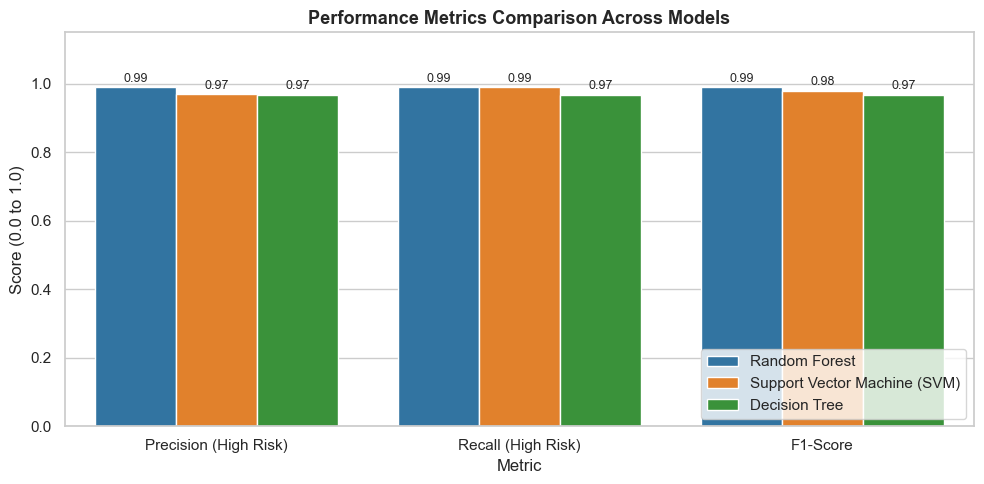

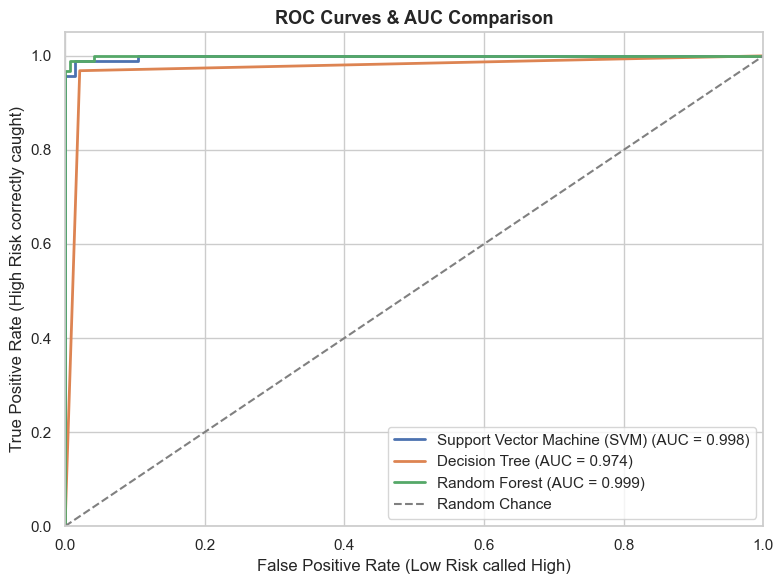

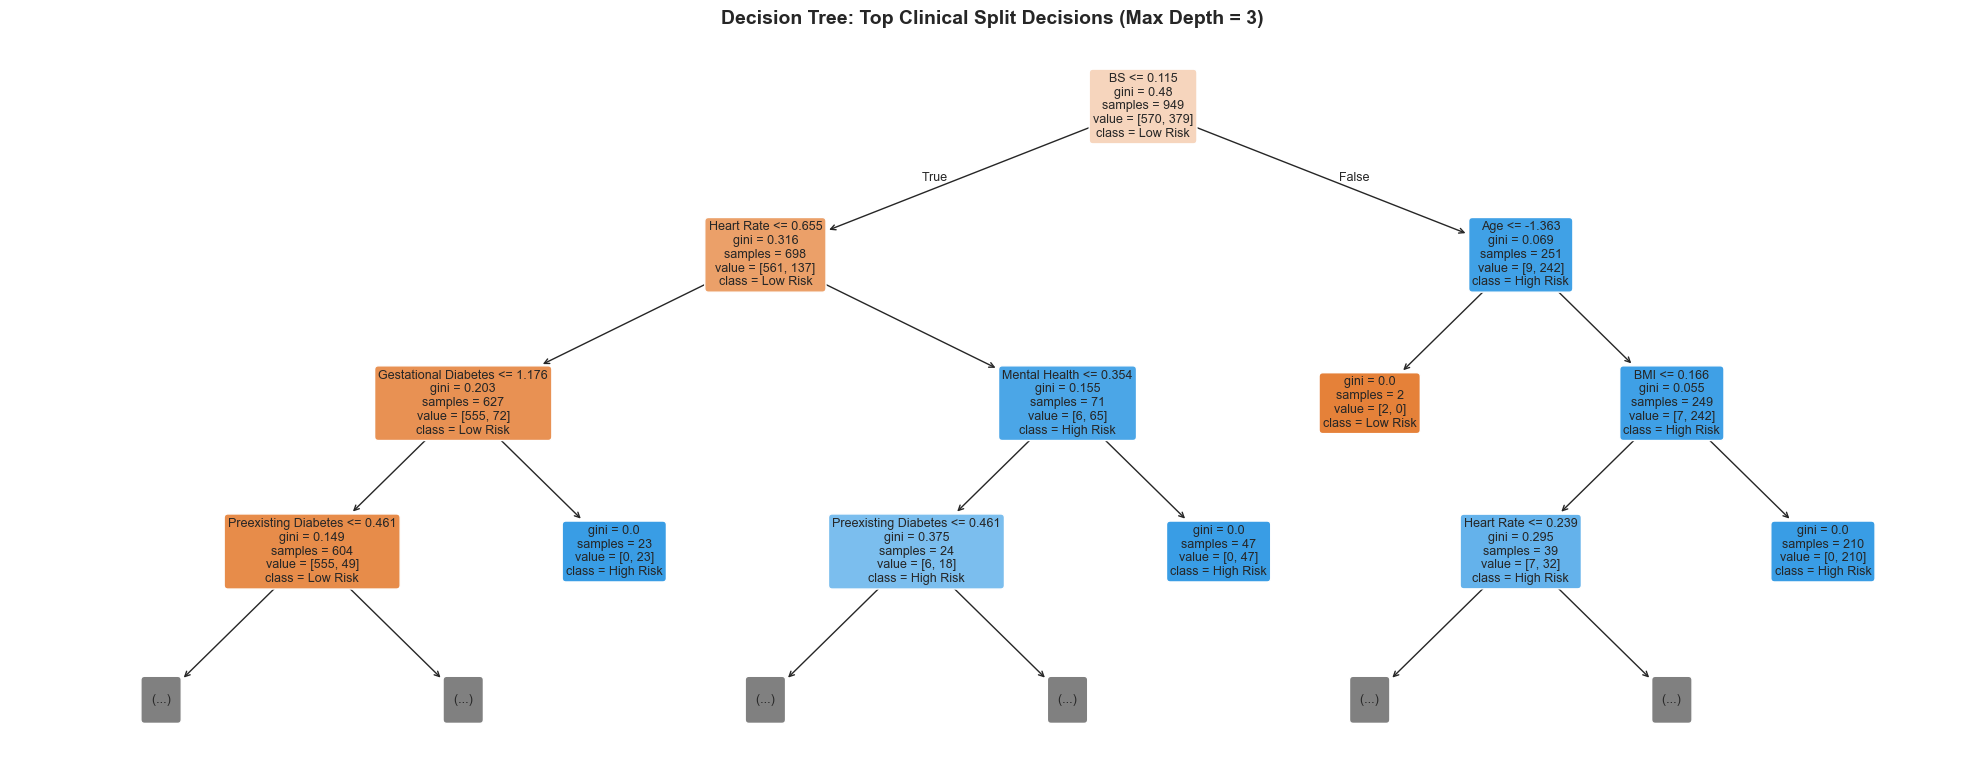

In [15]:
# ==============================================================================
# VISUALIZING THE 3 MODELS (METRICS COMPARISON, ROC CURVES & DECISION TREE)
# ==============================================================================
# What we are doing here:
# 1. Grouped Bar Chart: Directly compare Accuracy, Precision, Recall, F1 side-by-side.
# 2. ROC Curves: Compare sensitivity vs false alarms across models on one plot.
# 3. Decision Tree Diagram: Visualize the exact clinical questions the tree asks.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree

# ------------------------------------------------------------------------------
# 1. GROUPED BAR CHART: METRICS COMPARISON
# ------------------------------------------------------------------------------
# Melt the leaderboard DataFrame into long format for Seaborn
plot_data = pd.melt(
    leaderboard, 
    id_vars=['Model'], 
    value_vars=['Precision (High Risk)', 'Recall (High Risk)', 'F1-Score'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model', palette='tab10')
plt.title('Performance Metrics Comparison Across Models', fontsize=13, weight='bold')
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1.15)

# Annotate values on top of bars
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='bottom', fontsize=9, xytext=(0, 2),
                           textcoords='offset points')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. ROC CURVES (RECEIVER OPERATING CHARACTERISTIC)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # SVM requires decision_function; Trees/Forest use predict_proba
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.decision_function(X_test_scaled)
        
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 50/50 baseline reference line
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.5, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Low Risk called High)')
plt.ylabel('True Positive Rate (High Risk correctly caught)')
plt.title('ROC Curves & AUC Comparison', fontsize=13, weight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. DECISION TREE LOGIC FLOWCHART (Pruned to Depth 3 for Readability)
# ------------------------------------------------------------------------------
plt.figure(figsize=(20, 8))
plot_tree(
    models["Decision Tree"],
    max_depth=3, # Capped at 3 levels so text remains clearly readable
    feature_names=X.columns,
    class_names=['Low Risk', 'High Risk'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree: Top Clinical Split Decisions (Max Depth = 3)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ==============================================================================
# MODEL COMPARISON & VERDICT SCORECARD (WITH SPECIFICITY)
# ==============================================================================
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Calculate Specificity for each model from predictions
specificity_dict = {}
for name, y_pred in predictions.items():
    # Confusion matrix returns: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)
    specificity_dict[name] = round(spec, 3)

# 2. Format the comparison table
comparison_df = pd.DataFrame(metrics_list).set_index("Model")
comparison_df["Specificity (Low Risk)"] = comparison_df.index.map(specificity_dict)

# 3. Add clinical rankings
comparison_df["Recall Rank"] = comparison_df["Recall (High Risk)"].rank(ascending=False).astype(int)
comparison_df["Specificity Rank"] = comparison_df["Specificity (Low Risk)"].rank(ascending=False).astype(int)
comparison_df["F1-Score Rank"] = comparison_df["F1-Score"].rank(ascending=False).astype(int)

print("=" * 40 + " FINAL COMPARISON TABLE " + "=" * 40)
display(comparison_df.sort_values(by="F1-Score", ascending=False))

# 4. Extract best models per clinical criteria
best_recall_model = comparison_df["Recall (High Risk)"].idxmax()
best_spec_model = comparison_df["Specificity (Low Risk)"].idxmax()
best_f1_model = comparison_df["F1-Score"].idxmax()
best_acc_model = comparison_df["Accuracy (%)"].idxmax()

print("\n" + "=" * 40 + " METRIC DECISION RULES " + "=" * 40)
print(f"• Highest Accuracy:    {best_acc_model} ({comparison_df.loc[best_acc_model, 'Accuracy (%)']}%)")
print(f"• Highest Recall:      {best_recall_model} ({comparison_df.loc[best_recall_model, 'Recall (High Risk)']}) -> *Best at catching High-Risk cases*")
print(f"• Highest Specificity: {best_spec_model} ({comparison_df.loc[best_spec_model, 'Specificity (Low Risk)']}) -> *Best at ruling out Low-Risk (fewest false alarms)*")
print(f"• Highest F1-Score:    {best_f1_model} ({comparison_df.loc[best_f1_model, 'F1-Score']}) -> *Best overall balance*")

======================================== FINAL COMPARISON TABLE ========================================


,Accuracy (%),Precision (High Risk),Recall (High Risk),F1-Score,Specificity (Low Risk),Recall Rank,Specificity Rank,F1-Score Rank
Model,,,,,,,,
Random Forest,99.16,0.989,0.989,0.989,0.993,1,1,1
Support Vector Machine (SVM),98.32,0.969,0.989,0.979,0.979,1,2,2
Decision Tree,97.48,0.968,0.968,0.968,0.979,3,2,3



======================================== METRIC DECISION RULES ========================================
• Highest Accuracy:    Random Forest (99.16%)
• Highest Recall:      Support Vector Machine (SVM) (0.989) -> *Best at catching High-Risk cases*
• Highest Specificity: Random Forest (0.993) -> *Best at ruling out Low-Risk (fewest false alarms)*
• Highest F1-Score:    Random Forest (0.989) -> *Best overall balance*


In [18]:
# ==============================================================================
# STEP 9: SAVE TRAINED MODEL & SCALER FOR PRODUCTION USE
# ==============================================================================
import joblib

# 1. Select the winning model
winning_model = models["Random Forest"]

# 2. Save both the model and the fitted scaler
joblib.dump(winning_model, "maternal_risk_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved successfully:")
print("1. 'maternal_risk_rf_model.pkl' (Trained Random Forest)")
print("2. 'scaler.pkl' (Fitted StandardScaler)")

Files saved successfully:
1. 'maternal_risk_rf_model.pkl' (Trained Random Forest)
2. 'scaler.pkl' (Fitted StandardScaler)


In [19]:
# ==============================================================================
# STEP 10: INFERENCE / PREDICTION ON A NEW PATIENT
# ==============================================================================
import numpy as np
import pandas as pd
import joblib

# Load the saved model and scaler
loaded_scaler = joblib.load("scaler.pkl")
loaded_model = joblib.load("maternal_risk_rf_model.pkl")

def assess_patient_risk(patient_vitals: dict):
    # Ensure correct feature ordering
    df_patient = pd.DataFrame([patient_vitals])
    
    # Scale features using the saved scaler
    patient_scaled = loaded_scaler.transform(df_patient)
    
    # Predict class and probability
    pred = loaded_model.predict(patient_scaled)[0]
    prob = loaded_model.predict_proba(patient_scaled)[0]
    
    risk_label = "HIGH RISK" if pred == 1 else "LOW RISK"
    confidence = prob[pred] * 100
    
    print("=" * 35 + " PATIENT DIAGNOSIS " + "=" * 35)
    print(f"Predicted Diagnosis: {risk_label}")
    print(f"Model Confidence:    {confidence:.2f}%")
    print(f"Risk Probabilities:  Low: {prob[0]*100:.1f}% | High: {prob[1]*100:.1f}%")

# Example: High-risk patient profile (elevated BP and Blood Sugar)
sample_patient = {
    'Age': 35,
    'Systolic BP': 140,
    'Diastolic': 95,
    'BS': 11.0,
    'Body Temp': 98,
    'BMI': 31.5,
    'Previous Complications': 1,
    'Preexisting Diabetes': 1,
    'Gestational Diabetes': 0,
    'Mental Health': 0,
    'Heart Rate': 88
}

assess_patient_risk(sample_patient)

=================================== PATIENT DIAGNOSIS ===================================
Predicted Diagnosis: HIGH RISK
Model Confidence:    100.00%
Risk Probabilities:  Low: 0.0% | High: 100.0%


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [20]:
import os

folder_path = os.getcwd()

print("Your files are saved here:")
print(folder_path)

print("\nFiles in this folder:")
for f in os.listdir(folder_path):
    if f.endswith('.pkl'):
        print(f" -> {os.path.join(folder_path, f)}")

Your files are saved here:
c:\Users\cse\Desktop\Maternal

Files in this folder:
 -> c:\Users\cse\Desktop\Maternal\maternal_risk_rf_model.pkl
 -> c:\Users\cse\Desktop\Maternal\scaler.pkl


In [21]:
# ==============================================================================
# SAVE ALL EDA CHARTS, MODEL VISUALIZATIONS, AND METRICS TO SEPARATE FILES
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.tree import plot_tree

# 1. Create output folder in current working directory
output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)
print(f"Saving all outputs to: {output_dir}\n")

# ------------------------------------------------------------------------------
# A. SAVE DATA TABLES & METRICS AS CSV FILES
# ------------------------------------------------------------------------------
# 1. Descriptive stats
df_prep.describe().T.round(2).to_csv(os.path.join(output_dir, "1_descriptive_statistics.csv"))

# 2. Correlation matrix table
corr_matrix.round(3).to_csv(os.path.join(output_dir, "2_correlation_matrix.csv"))

# 3. Model performance comparison leaderboard (with specificity & rankings)
comparison_df.to_csv(os.path.join(output_dir, "3_model_comparison_leaderboard.csv"))

print("CSV files saved:")
print(" - 1_descriptive_statistics.csv")
print(" - 2_correlation_matrix.csv")
print(" - 3_model_comparison_leaderboard.csv")

# ------------------------------------------------------------------------------
# B. SAVE EDA VISUALIZATIONS (PNG)
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")

# 4. EDA 4-Panel Overview Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
counts = df_prep['Risk Level'].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=['#4C72B0', '#C44E52'])
axes[0, 0].set_title('Target Distribution', fontsize=12, weight='bold')

avg_bs = df_prep.groupby('Risk Level')['BS'].mean().loc[counts.index]
axes[0, 1].bar(avg_bs.index, avg_bs.values, color=['#4C72B0', '#C44E52'])
axes[0, 1].set_title('Mean BS by Risk Level', fontsize=12, weight='bold')

sns.scatterplot(data=df_prep, x='Diastolic', y='Systolic BP', hue='Risk Level', ax=axes[1, 0])
axes[1, 0].set_title('Systolic vs Diastolic BP', fontsize=12, weight='bold')

sns.scatterplot(data=df_prep, x='Age', y='BS', hue='Risk Level', ax=axes[1, 1])
axes[1, 1].set_title('Age vs Blood Sugar', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "4_eda_patterns_panel.png"), dpi=300)
plt.close()

# 5. Correlation Heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "5_correlation_heatmap.png"), dpi=300)
plt.close()

# ------------------------------------------------------------------------------
# C. SAVE MODEL PERFORMANCE VISUALIZATIONS (PNG)
# ------------------------------------------------------------------------------
# 6. Grouped Performance Metrics Bar Chart
plot_data = pd.melt(
    leaderboard, 
    id_vars=['Model'], 
    value_vars=['Precision (High Risk)', 'Recall (High Risk)', 'F1-Score'],
    var_name='Metric', 
    value_name='Score'
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model', palette='tab10')
plt.title('Performance Metrics Comparison', fontsize=13, weight='bold')
plt.ylim(0, 1.15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "6_metrics_comparison_barchart.png"), dpi=300)
plt.close()

# 7. Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Low (0)', 'High (1)'], yticklabels=['Low (0)', 'High (1)'], ax=ax)
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "7_confusion_matrices.png"), dpi=300)
plt.close()

# 8. ROC Curves & AUC Comparison
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('ROC Curves Comparison', fontsize=13, weight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "8_roc_curves.png"), dpi=300)
plt.close()

# 9. Decision Tree Architecture Diagram
plt.figure(figsize=(22, 10))
plot_tree(models["Decision Tree"], max_depth=3, feature_names=X.columns,
          class_names=['Low Risk', 'High Risk'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Decision Logic (Depth=3)", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "9_decision_tree_flowchart.png"), dpi=300)
plt.close()

# 10. Random Forest Feature Importance Chart
plt.figure(figsize=(10, 6))
pd.Series(models["Random Forest"].feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='#2b5c8f')
plt.title("Random Forest Clinical Feature Importance", fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "10_feature_importance.png"), dpi=300)
plt.close()

print("\nPNG visualization files saved successfully:")
print(" - 4_eda_patterns_panel.png")
print(" - 5_correlation_heatmap.png")
print(" - 6_metrics_comparison_barchart.png")
print(" - 7_confusion_matrices.png")
print(" - 8_roc_curves.png")
print(" - 9_decision_tree_flowchart.png")
print(" - 10_feature_importance.png")
print("\nAll files are written to the 'outputs' folder in your directory.")

Saving all outputs to: c:\Users\cse\Desktop\Maternal\outputs

CSV files saved:
 - 1_descriptive_statistics.csv
 - 2_correlation_matrix.csv
 - 3_model_comparison_leaderboard.csv

PNG visualization files saved successfully:
 - 4_eda_patterns_panel.png
 - 5_correlation_heatmap.png
 - 6_metrics_comparison_barchart.png
 - 7_confusion_matrices.png
 - 8_roc_curves.png
 - 9_decision_tree_flowchart.png
 - 10_feature_importance.png

All files are written to the 'outputs' folder in your directory.
